## Le Reseau Artificiel à 2 couches

In [1]:
# Importation des librairries necessaires
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons

In [9]:
# Generation d'un dataset a separabilite non lineaire
X, y = make_moons(n_samples = 100, noise = 0.1, random_state = 0)

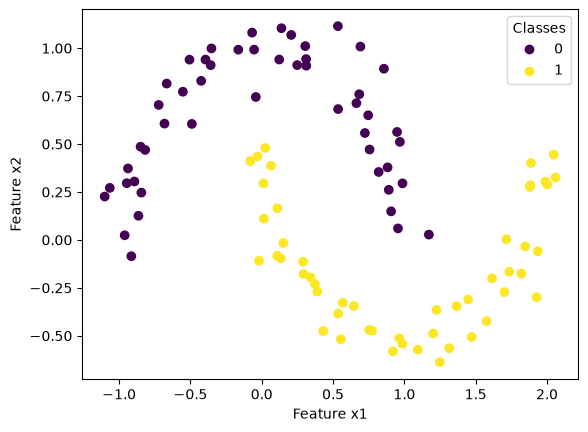

In [10]:
# Creation d'une troisieme features sur une echelle differente
x3 = np.where(y == 1, np.random.randint(20, 30, 100), np.random.randint(30, 40, 100))
x3 = x3.reshape((X.shape[0], 1))

# Creation du vecteur unitaire pour le biais
unit_vector = np.ones(X.shape[0], int)
unit_vector = unit_vector.reshape((unit_vector.shape[0], 1))

# Refermatage de la matrice des features et du vecteur target
X = np.concatenate((X, x3, unit_vector), axis = 1)
y = y.reshape((y.shape[0], 1))

# Visualisation des donnees
scatter_plot = plt.scatter(X[:, 0], X[:, 1], c = y)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend(*scatter_plot.legend_elements(), loc='best', title='Classes')

Le dataset a été généré grâce à la fonction make_moons() du package sklearn. 
Dans la ci-haut, nous représentons les données sur un nuage de points, en considérant uniquement les deux premières caractéristiques. 
Il en ressort que les deux classes ne sont pas linéairement sépérables. 
Cette situation est la plus fréquemment rencontrée dans des applications réelles, et les réseaux de neurones ont la capacité de résoudre de tels problèmes.

In [17]:
# Statistiques descriptives
means = np.mean(X[:, :3], axis = 0)
stds = np.std(X[:, :3], axis = 0)
minimum = np.min(X[:, :3], axis = 0)
maximum = np.max(X[:, :3], axis = 0)
quartiles = np.percentile(X[:, :3], [25, 50, 75], axis = 0)

Il est à noter que la troisième caractéristique se situe à une échelle différente des deux premières (cf. Tableau suivant). En effet, les réseaux de neurones sont sensibles aux différences dans les échelles des données des variables explicatives. C’est ce qu’on appelle le “feature scaling”. 
Si les plages de valeurs des caractéristiques d’entrée sont très différentes, cela peut entrâıner des problèmes de convergence de l’algorithme d’optimisation, ce qui peut endommager la performance du modèle en réseau de neurones. Pour surmonter cet obstacle, il est nécessaire de rédimensionner les données au moyen notamment de la standardisation. 
Cette technique consiste à soustraire la moyenne de chaque caractéristique et à la diviser par l’écart-type. Cela permet de ramener toutes les caractéristiques à une moyenne de 0 et à une variance de 1, et donc sur des échelles assez semblables.
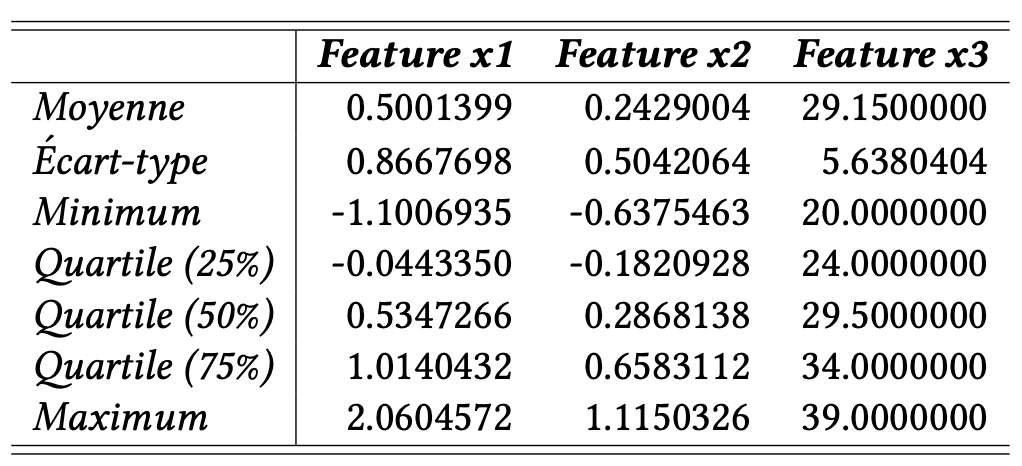

In [19]:
# Standardisation
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit(X[:, :3]).transform(X[:, :3])
X_scaled = np.concatenate((X_scaled, unit_vector), axis = 1)

# Statistiques descriptives
means_s = np.mean(X_scaled[:, :3], axis = 0)
stds_s = np.std(X_scaled[:, :3], axis = 0)
minimum_s = np.min(X_scaled[:, :3], axis = 0)
maximum_s = np.max(X_scaled[:, :3], axis = 0)
quartiles_s = np.percentile(X_scaled[:, :3], [25, 50, 75], axis = 0)

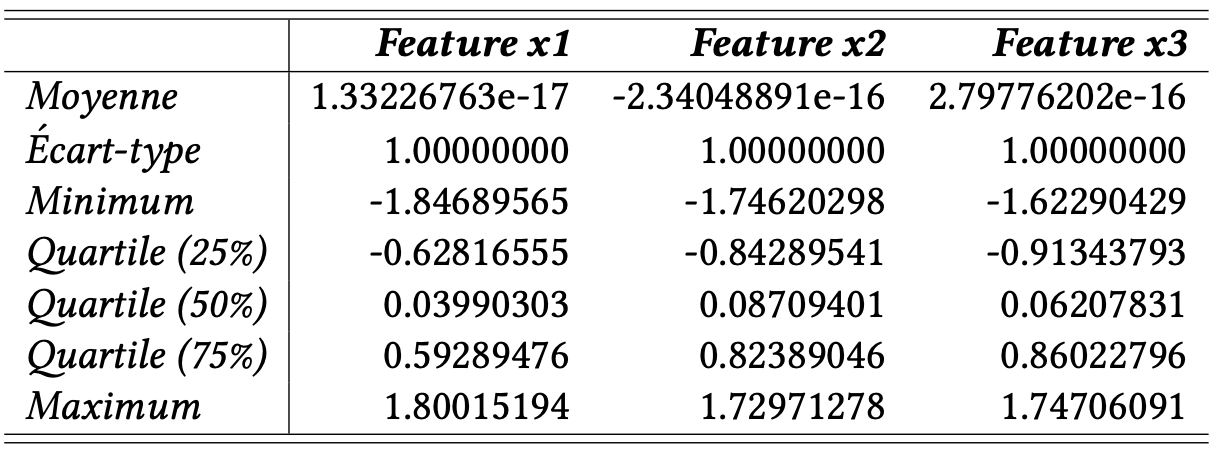

### Définition de la fonction d'initialisation

In [20]:
# Fonction d'initialisation
def initialize(m, p1, p2):
    np.random.seed(0)
    W1 = np.random.randn(m, p1)
    W2 = np.random.randn(p1, p2)
    
    parametres  = {
        'W1': W1,
        'W2': W2
    }
    return parametres

### Définition des fonctions d'agrégration et d'activation

In [38]:
# Equation de la forward progration
def forward_propagation(X, parametres):
    Z1 = X.dot(parametres['W1'])
    A1 = 1 / (1 + np.exp(-Z1))
    
    Z2 = A1.dot(parametres['W2'])
    A2 = 1 / (1 + np.exp(-Z2))
    
    activations = {
        'A1': A1,
        'A2': A2
    }
    return activations

### Définition de la fonction-coût

In [39]:
# Fonction-cout
def log_loss(activation, y):
    Aq = activation['A2']
    L = -1/len(y)*np.sum((y*np.log(Aq)) + ((1 - y)*np.log(1-Aq)))
    return L

### Definition des valeurs jacobiens

In [40]:
# Equation de la backward propagation
def backward_propagation(parametres, activations, X, y):
    A1 = activations['A1']
    A2 = activations['A2']
    W2 = parametres['W2']
    
    dW2 = 1 /len(y)*np.dot(A1.T, (A2 - y))
    dW1 = 1/len(y)*np.dot(X.T, (np.dot((A2 - y), W2.T)*(A1*(1-A1))))
    
    jacobiens = {
        'dW2': dW2,
        'dW1': dW1
    }
    return jacobiens

### Definition de la fonction de mise a jour

In [41]:
# Actualisaiton des parametres
def update(parametres, jacobiens, learning_rate):
    W1 = parametres['W1']
    W2 = parametres['W2']
    
    dW1 = jacobiens['dW1']
    dW2 = jacobiens['dW2']
    
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    
    parametres = {
        'W1': W1,
        'W2': W2
    }
    return parametres

### Definition de la fonction de prediction

In [42]:
# Fonction de prediction
def predict(X, parametres):
    activations = forward_propagation(X, parametres)
    A2 = activations['A2']
    y_pred = []
    
    for i in range(X.shape[0]):
        if A2[i] >= .5:
            y_pred.append(1)
        else:
            y_pred.append(0)
    return y_pred

Après avoir codé toutes les équations en Python, procédons à présent au codage de l’algorithme d’optimisation.
Ce code permettra de visualiser l’évolution de la valeur du coût à travers les itérations, et de retourner les valeurs optimales des paramètres du modèle. Les détails sur les sorties de chaque bloc de codes sont disponibles ici.

In [43]:
# Algorithme d'optimisation
def ANN(X, y, m, p1, p2, learning_rate, n_iterations):
    parametres = initialize(m, p1, p2)
    L = []
    for h in range(n_iterations):
        activations = forward_propagation(X, parametres)
        A2 = activations['A2']
        
        L.append(log_loss(activations, y))
        jacobiens = backward_propagation(parametres, activations, X, y)
        parametres = update(parametres, jacobiens, learning_rate)
    
    plt.plot(L)
    plt.xlabel('Iterations')
    plt.ylabel('Cout')
    plt.show()
    
    return parametres

Pour entraîıner le modèle, le taux d’apprentissage a été fixé à α = 0.1 et le nombre d’itérations à H = 1000. 
Nous avons considéré deux neurones pour la première couche, et un seul pour la seconde.

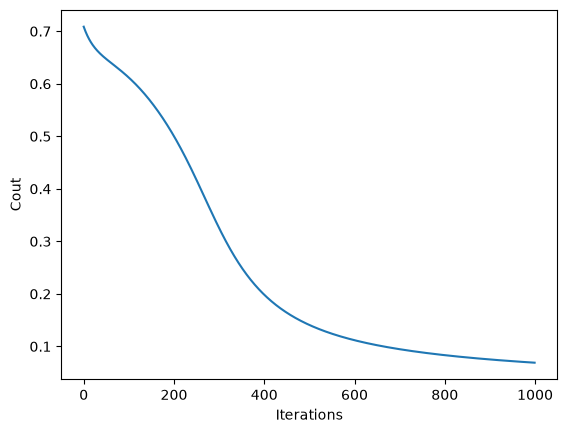

{'W1': array([[ 0.0573263 ,  0.90446637],
       [ 1.71532255,  0.07370372],
       [ 3.40179692, -3.0182082 ],
       [ 0.0873322 ,  0.04612706]]), 'W2': array([[-3.97001727],
       [ 3.72730065]])}


In [44]:
# Entrainement du modele
parametres = ANN(X = X_scaled, y = y, m =X_scaled.shape[1], p1 = 2, p2 =1, learning_rate = .1, n_iterations = 1000)
print(parametres)

In [46]:
# Matrice de confusion
def confusion_matrix(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    n_classes = np.unique(y_true).shape[0]
    confusion_matrix = np.zeros((n_classes, n_classes))
    
    for i in range(len(y_true)):
        confusion_matrix[y_true[i], y_pred[i]] += 1
        
    return confusion_matrix

y_pred = predict(X_scaled, parametres)
cm = confusion_matrix(y_true = y, y_pred = y_pred)
print(cm)

[[49.  1.]
 [ 0. 50.]]


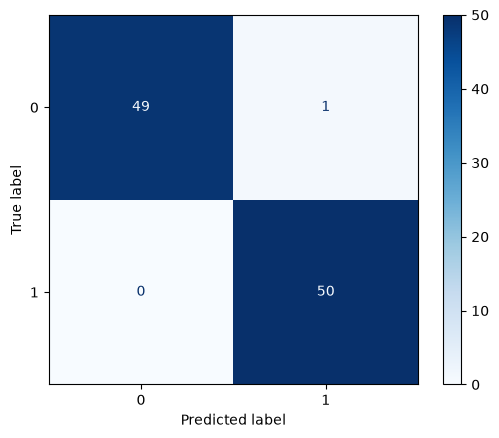

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap="Blues")
plt.show()

In [48]:
# Accuracy
def accuracy(confusion_matrix):
    diag = np.diag(confusion_matrix, k = 0)
    n_correct = diag.sum()
    n_total = confusion_matrix.sum()
    accuracy = n_correct / n_total
    return accuracy

acc = accuracy(cm)
print(acc)

0.99


Partant des codes précédemment écrits, il est possible d’entrainer d’autres modèles de réseau comportant un nombre plus élevé de neurones dans les deux couches masquées. 
Il suffira pour cela de faire varier les arguments p1 et p2 de la fonction ANN(). 
L’on pourra alors se poser la question du choix judicieux de ces deux arguments, mais également des valeurs optimales du taux d’apprentissage et du nombre d’itérations.

In [49]:
# Definition de la grille pour la frontiere de decision
h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [50]:
# Predire la classe pour chaque point de la grille
weights = {'W1': parametres['W1'][[0,1]], 'W2': parametres['W2']}
grid_points = np.c_[xx.ravel(), yy.ravel()]
predictions = predict(grid_points, weights)

In [51]:
# Reformatage des predictions en fonction de la grille
predictions = np.array(predictions)
predictions = predictions.reshape(xx.shape)

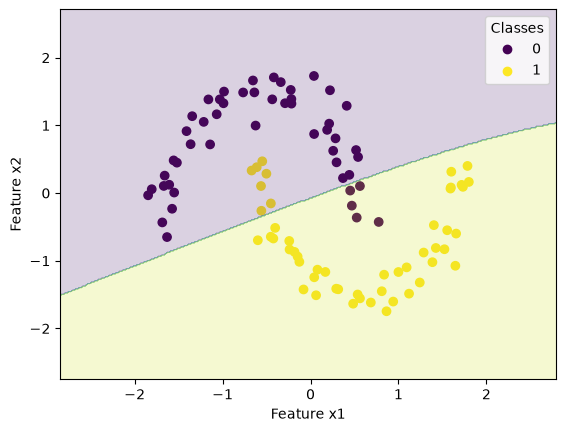

In [54]:
# Tracage de la frontiere de decision non-lineaire
scatter_plot = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c = y)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend(*scatter_plot.legend_elements(), loc = 'best', title = 'Classes')
plt.contourf(xx, yy, predictions, alpha=0.2);

La Figure ci-haut révèle que la prise en compte de la sépérabilité non-linéaire des classes à prédire a amélioré la performance du modèle. 
En effet, le modèle ajusté accuse une accuracy de 99%, ce qui peut sembler très intéressant à première vue. Cependant, une performance très élevée dans la phase d’apprentissage est aussi susceptible de présager le problème “overfitting”. L’overfitting (sur-apprentissage) se produit lorsqu’un modèle de Machine Learning est exagérément adapté aux données d’entraînement au point de ne plus parvenir à se généraliser à des données nouvelles. 
Une solution à ce problème consiste à faire recours à la “validation croisée”, telle que discutée dans la section suivante.